<a href="https://colab.research.google.com/github/rajrajraj6383371752-design/MLA0201-FOML/blob/main/FOML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1 Implement and demonstrate the FIND-S algorithm for finding the most specific hypothesis based on a given set of training data samples.  

In [ ]:
# FIND-S Algorithm Implementation

# Training dataset
training_data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
]

# Initialize hypothesis with the most specific values
hypothesis = ['0', '0', '0', '0', '0', '0']

print("Training Data:")
for row in training_data:
    print(row)

print("\nFIND-S Algorithm Steps:")

# Process each training example
for i, example in enumerate(training_data):

    # Consider only positive examples
    if example[-1] == 'Yes':

        # First positive example
        if hypothesis == ['0', '0', '0', '0', '0', '0']:
            hypothesis = example[:-1]
        else:
            # Generalize hypothesis when attributes differ
            for j in range(len(hypothesis)):
                if hypothesis[j] != example[j]:
                    hypothesis[j] = '?'

        print(f"After Example {i + 1}: {hypothesis}")

# Display final hypothesis
print("\nFinal Most Specific Hypothesis:")
print(hypothesis)

Training Data:
['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes']
['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes']
['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No']
['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']

FIND-S Algorithm Steps:
After Example 1: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
After Example 2: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
After Example 4: ['Sunny', 'Warm', '?', 'Strong', '?', '?']

Final Most Specific Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


2 For a given set of training data examples stored in a .CSV file, implement and demonstrate the Candidate-Elimination algorithm in python to output a description of the set of all hypotheses consistent with the training examples

In [ ]:
import pandas as pd

# Create training dataset
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'Temperature': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

print("Training Data:")
print(df)

# Initialize Specific (S) hypothesis
S = ['0'] * 6

# Initialize General (G) hypothesis
G = [['?'] * 6]

# Candidate Elimination Algorithm
for i, row in df.iterrows():
    x = row.iloc[:6].tolist()
    label = row.iloc[6]

    if label == 'Yes':
        # Remove inconsistent hypotheses from G
        G = [g for g in G if all(g[j] == '?' or g[j] == x[j] for j in range(6))]

        # Generalize S
        for j in range(6):
            if S[j] == '0':
                S[j] = x[j]
            elif S[j] != x[j]:
                S[j] = '?'

    else:
        # Specialize G
        new_G = []

        for g in G:
            for j in range(6):
                if g[j] == '?':
                    if S[j] != '?' and S[j] != '0' and S[j] != x[j]:
                        h = g.copy()
                        h[j] = S[j]
                        new_G.append(h)

        G = new_G

    print("\nAfter Example", i + 1)
    print("Specific Hypothesis (S):", S)
    print("General Hypothesis (G):", G)

print("\nFinal Specific Hypothesis:")
print(S)

print("\nFinal General Hypothesis:")
for g in G:
    print(g)

Training Data:
     Sky Temperature Humidity    Wind Water Forecast EnjoySport
0  Sunny        Warm   Normal  Strong  Warm     Same        Yes
1  Sunny        Warm     High  Strong  Warm     Same        Yes
2  Rainy        Cold     High  Strong  Warm   Change         No
3  Sunny        Warm     High  Strong  Cool   Change        Yes

After Example 1
Specific Hypothesis (S): ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
General Hypothesis (G): [['?', '?', '?', '?', '?', '?']]

After Example 2
Specific Hypothesis (S): ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
General Hypothesis (G): [['?', '?', '?', '?', '?', '?']]

After Example 3
Specific Hypothesis (S): ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
General Hypothesis (G): [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', 'Same']]

After Example 4
Specific Hypothesis (S): ['Sunny', 'Warm', '?', 'Strong', '?', '?']
General Hypothesis (G): [['Sunny', '?', '?', '?', '?', '?

3 Demonstrate the working of the decision tree based ID3 algorithm. Use an appropriate data set for building the decision tree and apply this knowledge to classify a new sample.

Dataset:
     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No


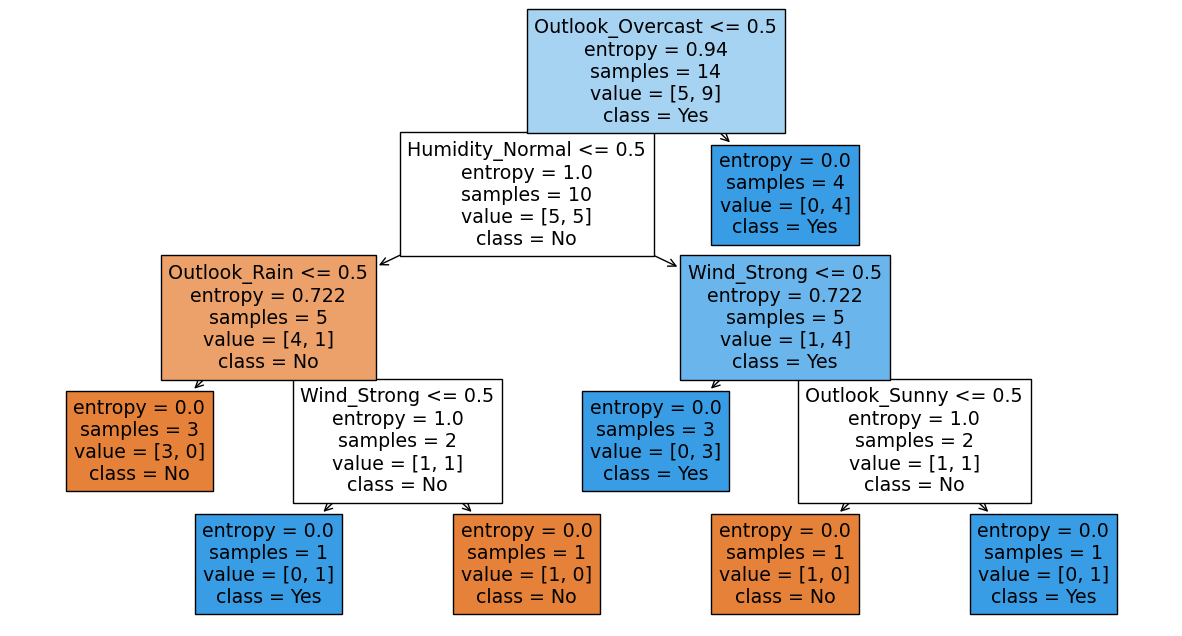

New Sample Prediction: No


In [ ]:
# ID3 Decision Tree Algorithm

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain',
                'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast',
                'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild',
                    'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High',
                 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
             'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes',
             'Yes', 'No']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Convert categorical values to numerical values
X = pd.get_dummies(df.drop('Play', axis=1))
y = df['Play'].map({'No': 0, 'Yes': 1})

# Build ID3 Decision Tree
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)

# Display tree
plt.figure(figsize=(15, 8))
plot_tree(model, feature_names=X.columns,
          class_names=['No', 'Yes'], filled=True)
plt.show()

# Classify a new sample
new_sample = pd.DataFrame([{
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}])

new_sample = pd.get_dummies(new_sample)
new_sample = new_sample.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_sample)

print("New Sample Prediction:",
      "Yes" if prediction[0] == 1 else "No")

4 Build an Artificial Neural Network by implementing the Backpropagation algorithm and test the same using appropriate data sets.

In [ ]:
# Artificial Neural Network using Backpropagation

import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Dataset: XOR
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Create Neural Network
model = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='relu',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Display results
print("Test Data:")
print(X_test)

print("\nActual Output:")
print(y_test)

print("\nPredicted Output:")
print(y_pred)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

# Test all XOR inputs
print("\nXOR Predictions:")
for sample in X:
    print(sample, "=>", model.predict([sample])[0])

Test Data:
[[0 1]]

Actual Output:
[1]

Predicted Output:
[0]

Accuracy:
0.0

XOR Predictions:
[0 0] => 0
[0 1] => 0
[1 0] => 1
[1 1] => 0


5 Write a program for Implementation of K-Nearest Neighbours (K-NN) in Python

In [ ]:
# K-Nearest Neighbours (K-NN) Algorithm

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Dataset
data = {
    'Age': [18, 20, 22, 25, 28, 30, 35, 40, 45, 50],
    'Salary': [15000, 18000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 60000],
    'Class': ['Low', 'Low', 'Low', 'Low', 'Medium',
              'Medium', 'Medium', 'High', 'High', 'High']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['Age', 'Salary']]
y = df['Class']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create K-NN model
knn = KNeighborsClassifier(n_neighbors=3)

# Train model
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

print("\nActual Output:")
print(y_test.values)

print("\nPredicted Output:")
print(y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# Predict a new sample
new_sample = [[27, 28000]]
prediction = knn.predict(new_sample)

print("\nNew Sample:", new_sample)
print("Predicted Class:", prediction[0])

Dataset:
   Age  Salary   Class
0   18   15000     Low
1   20   18000     Low
2   22   20000     Low
3   25   25000     Low
4   28   30000  Medium
5   30   35000  Medium
6   35   40000  Medium
7   40   45000    High
8   45   50000    High
9   50   60000    High

Actual Output:
['High' 'Low']

Predicted Output:
['High' 'Low']

Accuracy: 1.0

New Sample: [[27, 28000]]
Predicted Class: Medium


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


6 Write a program to implement Naïve Bayes algorithm in python and to display the results  using confusion matrix and accuracy.

In [ ]:
# Naive Bayes Classification with Confusion Matrix and Accuracy

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# Dataset
data = {
    'Age': [22, 25, 28, 30, 35, 40, 45, 50, 55, 60],
    'Salary': [20000, 25000, 28000, 30000, 35000, 40000, 45000, 50000, 55000, 60000],
    'Purchased': ['No', 'No', 'No', 'Yes', 'Yes',
                  'Yes', 'Yes', 'Yes', 'Yes', 'Yes']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['Age', 'Salary']]
y = df['Purchased']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Naive Bayes model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nActual Output:")
print(y_test.values)

print("\nPredicted Output:")
print(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Dataset:
   Age  Salary Purchased
0   22   20000        No
1   25   25000        No
2   28   28000        No
3   30   30000       Yes
4   35   35000       Yes
5   40   40000       Yes
6   45   45000       Yes
7   50   50000       Yes
8   55   55000       Yes
9   60   60000       Yes

Actual Output:
['Yes' 'No' 'Yes']

Predicted Output:
['Yes' 'No' 'Yes']

Confusion Matrix:
[[1 0]
 [0 2]]

Accuracy: 1.0
Accuracy (%): 100.0


7 Write a program to implement Logistic Regression (LR) algorithm in python

In [ ]:
# Logistic Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Dataset
data = {
    'Age': [20, 22, 25, 28, 30, 32, 35, 38, 40, 45],
    'Salary': [15000, 18000, 22000, 28000, 32000, 35000, 40000, 45000, 50000, 60000],
    'Purchased': [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['Age', 'Salary']]
y = df['Purchased']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("\nActual Output:")
print(y_test.values)

print("\nPredicted Output:")
print(y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Predict a new sample
new_sample = [[27, 26000]]
prediction = model.predict(new_sample)

print("\nNew Sample:", new_sample)
print("Predicted Class:", prediction[0])

Dataset:
   Age  Salary  Purchased
0   20   15000          0
1   22   18000          0
2   25   22000          0
3   28   28000          1
4   30   32000          1
5   32   35000          1
6   35   40000          1
7   38   45000          1
8   40   50000          1
9   45   60000          1

Actual Output:
[1 0 1]

Predicted Output:
[1 0 1]

Accuracy: 1.0
Accuracy (%): 100.0

New Sample: [[27, 26000]]
Predicted Class: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


8 Write a program to implement Linear Regression (LR) algorithm in python

In [ ]:
# Linear Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Dataset
data = {
    'Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Marks': [35, 40, 45, 50, 55, 60, 65, 70, 75, 80]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['Hours']]
y = df['Marks']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nActual Marks:")
print(y_test.values)

print("\nPredicted Marks:")
print(y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("\nMean Squared Error:", mse)

# Predict for new input
new_hours = [[7]]
prediction = model.predict(new_hours)

print("\nHours Studied:", new_hours[0][0])
print("Predicted Marks:", prediction[0])

Dataset:
   Hours  Marks
0      1     35
1      2     40
2      3     45
3      4     50
4      5     55
5      6     60
6      7     65
7      8     70
8      9     75
9     10     80

Actual Marks:
[75 40]

Predicted Marks:
[75. 40.]

Mean Squared Error: 0.0

Hours Studied: 7
Predicted Marks: 65.0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


9 Compare  Linear and Polynomial Regression using Python

In [ ]:
# Compare Linear and Polynomial Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Dataset
data = {
    'Distance': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'Packages': [1, 2, 2, 3, 3, 4, 4, 5, 5, 6]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['Distance']]
y = df['Packages']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

# Polynomial Regression
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)
poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_test)

# Display results
print("\nActual Values:")
print(y_test.values)

print("\nLinear Regression Predictions:")
print(linear_pred)

print("\nPolynomial Regression Predictions:")
print(poly_pred)

# Calculate Mean Squared Error
linear_mse = mean_squared_error(y_test, linear_pred)
poly_mse = mean_squared_error(y_test, poly_pred)

print("\nLinear Regression MSE:", linear_mse)
print("Polynomial Regression MSE:", poly_mse)

# Predict a new value
new_distance = [[27]]

print("\nNew Distance:", new_distance[0][0])
print("Linear Regression Prediction:",
      linear_model.predict(new_distance)[0])
print("Polynomial Regression Prediction:",
      poly_model.predict(new_distance)[0])

Dataset:
   Distance  Packages
0         5         1
1        10         2
2        15         2
3        20         3
4        25         3
5        30         4
6        35         4
7        40         5
8        45         5
9        50         6

Actual Values:
[5 2]

Linear Regression Predictions:
[5.43103448 1.56896552]

Polynomial Regression Predictions:
[5.43103448 1.56896552]

Linear Regression MSE: 0.18579072532699187
Polynomial Regression MSE: 0.18579072532700075

New Distance: 27
Linear Regression Prediction: 3.4448275862068964
Polynomial Regression Prediction: 3.444827586206894


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


10 Write a Python Program to Implement Expectation & Maximization Algorithm

In [ ]:
# Expectation-Maximization (EM) Algorithm

import numpy as np
from sklearn.mixture import GaussianMixture

# Dataset
X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [2, 2],
    [8, 8],
    [8, 9],
    [9, 8],
    [9, 9]
])

print("Dataset:")
print(X)

# Apply EM algorithm using Gaussian Mixture Model
em = GaussianMixture(
    n_components=2,
    random_state=42
)

# Train the model
em.fit(X)

# Predict clusters
labels = em.predict(X)

print("\nCluster Labels:")
print(labels)

# Display cluster means
print("\nCluster Means:")
print(em.means_)

# Display probabilities
print("\nCluster Probabilities:")
print(em.predict_proba(X))

Dataset:
[[1 1]
 [1 2]
 [2 1]
 [2 2]
 [8 8]
 [8 9]
 [9 8]
 [9 9]]

Cluster Labels:
[0 0 0 0 1 1 1 1]

Cluster Means:
[[1.5 1.5]
 [8.5 8.5]]

Cluster Probabilities:
[[1.00000000e+00 5.22907872e-98]
 [1.00000000e+00 7.56174508e-86]
 [1.00000000e+00 7.56174508e-86]
 [1.00000000e+00 1.09350025e-73]
 [1.09350025e-73 1.00000000e+00]
 [7.56174508e-86 1.00000000e+00]
 [7.56174508e-86 1.00000000e+00]
 [5.22907872e-98 1.00000000e+00]]


11 Write a program for the task of Credit Score Classification

In [ ]:
# Credit Score Classification

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset
data = {
    'Income': [25000, 30000, 35000, 40000, 45000, 50000, 60000, 70000, 80000, 90000],
    'Age': [22, 25, 28, 30, 32, 35, 40, 45, 50, 55],
    'Loan_Amount': [10000, 12000, 15000, 18000, 20000, 22000, 25000, 28000, 30000, 35000],
    'Credit_Score': ['Poor', 'Poor', 'Poor', 'Average', 'Average',
                     'Average', 'Good', 'Good', 'Good', 'Good']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['Income', 'Age', 'Loan_Amount']]
y = df['Credit_Score']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nActual Credit Scores:")
print(y_test.values)

print("\nPredicted Credit Scores:")
print(y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict a new customer
new_customer = [[55000, 36, 20000]]
prediction = model.predict(new_customer)

print("\nNew Customer:")
print(new_customer)

print("Predicted Credit Score:", prediction[0])

Dataset:
   Income  Age  Loan_Amount Credit_Score
0   25000   22        10000         Poor
1   30000   25        12000         Poor
2   35000   28        15000         Poor
3   40000   30        18000      Average
4   45000   32        20000      Average
5   50000   35        22000      Average
6   60000   40        25000         Good
7   70000   45        28000         Good
8   80000   50        30000         Good
9   90000   55        35000         Good

Actual Credit Scores:
['Good' 'Poor' 'Average']

Predicted Credit Scores:
['Good' 'Poor' 'Average']

Accuracy: 1.0
Accuracy (%): 100.0

Confusion Matrix:
[[1 0 0]
 [0 1 0]
 [0 0 1]]

New Customer:
[[55000, 36, 20000]]
Predicted Credit Score: Average


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


12 Implement Iris Flower Classification using KNN

In [ ]:
# Iris Flower Classification using KNN

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Display results
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Predict a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = knn.predict(new_flower)

print("\nNew Flower Prediction:")
print(iris.target_names[prediction[0]])

Actual Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Predicted Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Accuracy: 1.0
Accuracy (%): 100.0

New Flower Prediction:
setosa


13 Implement the Car Price Prediction Model using Python

In [ ]:
# Car Price Prediction using Linear Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Dataset
data = {
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Kilometers': [80000, 70000, 60000, 50000, 45000, 40000, 30000, 25000, 15000, 10000],
    'Price': [400000, 450000, 500000, 550000, 600000,
              650000, 750000, 850000, 950000, 1100000]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['Year', 'Kilometers']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("\nActual Prices:")
print(y_test.values)

print("\nPredicted Prices:")
print(y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("\nMean Squared Error:", mse)

# Predict price for a new car
new_car = [[2022, 20000]]
prediction = model.predict(new_car)

print("\nNew Car Details:")
print("Year:", new_car[0][0])
print("Kilometers:", new_car[0][1])
print("Predicted Car Price:", prediction[0])

Dataset:
   Year  Kilometers    Price
0  2015       80000   400000
1  2016       70000   450000
2  2017       60000   500000
3  2018       50000   550000
4  2019       45000   600000
5  2020       40000   650000
6  2021       30000   750000
7  2022       25000   850000
8  2023       15000   950000
9  2024       10000  1100000

Actual Prices:
[950000 450000]

Predicted Prices:
[925000. 425000.]

Mean Squared Error: 625000000.0

New Car Details:
Year: 2022
Kilometers: 20000
Predicted Car Price: 825000.0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


14 Implement House price Prediction using appropriate machine learning algorithm

In [ ]:
# House Price Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Dataset
data = {
    'Area': [800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600],
    'Bedrooms': [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    'Age': [20, 18, 15, 12, 10, 8, 6, 5, 3, 2],
    'Price': [2500000, 3000000, 3600000, 4200000, 4800000,
              5500000, 6200000, 6800000, 7500000, 8200000]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['Area', 'Bedrooms', 'Age']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("\nActual House Prices:")
print(y_test.values)

print("\nPredicted House Prices:")
print(y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("\nMean Squared Error:", mse)

# Predict price for a new house
new_house = [[1500, 3, 8]]
prediction = model.predict(new_house)

print("\nNew House Details:")
print("Area:", new_house[0][0])
print("Bedrooms:", new_house[0][1])
print("Age:", new_house[0][2])

print("Predicted House Price:", prediction[0])

Dataset:
   Area  Bedrooms  Age    Price
0   800         2   20  2500000
1  1000         2   18  3000000
2  1200         3   15  3600000
3  1400         3   12  4200000
4  1600         3   10  4800000
5  1800         4    8  5500000
6  2000         4    6  6200000
7  2200         4    5  6800000
8  2400         5    3  7500000
9  2600         5    2  8200000

Actual House Prices:
[7500000 3000000]

Predicted House Prices:
[7495454.54545455 3077272.72727272]

Mean Squared Error: 2995867768.594839

New House Details:
Area: 1500
Bedrooms: 3
Age: 8
Predicted House Price: 4272348.484848484


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


15 Implement Iris Flower Classification using Naive Bayes classifier

In [ ]:
# Iris Flower Classification using Naive Bayes

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Naive Bayes model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Display results
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("\nNew Flower Prediction:")
print(iris.target_names[prediction[0]])

Actual Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Predicted Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Accuracy: 1.0
Accuracy (%): 100.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

New Flower Prediction:
setosa


16 Compare different types Classification Algorithms and evaluate their performance.

In [ ]:
# Compare Different Classification Algorithms

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(name)
    print("Accuracy:", accuracy)
    print("Accuracy (%):", accuracy * 100)
    print("-" * 40)

Logistic Regression
Accuracy: 1.0
Accuracy (%): 100.0
----------------------------------------
Decision Tree
Accuracy: 1.0
Accuracy (%): 100.0
----------------------------------------
KNN
Accuracy: 1.0
Accuracy (%): 100.0
----------------------------------------
Naive Bayes
Accuracy: 1.0
Accuracy (%): 100.0
----------------------------------------


17 Implement Mobile Price Prediction using appropriate machine learning algorithm

In [ ]:
# Mobile Price Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Dataset
data = {
    'RAM': [2, 2, 3, 3, 4, 4, 6, 6, 8, 8],
    'Storage': [32, 64, 64, 128, 128, 256, 128, 256, 256, 512],
    'Battery': [3000, 3500, 4000, 4500, 4000, 4500, 5000, 5000, 5000, 6000],
    'Price_Range': ['Low', 'Low', 'Low', 'Medium', 'Medium',
                    'Medium', 'High', 'High', 'High', 'High']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['RAM', 'Storage', 'Battery']]
y = df['Price_Range']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nActual Price Range:")
print(y_test.values)

print("\nPredicted Price Range:")
print(y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Predict a new mobile
new_mobile = [[6, 256, 5000]]
prediction = model.predict(new_mobile)

print("\nNew Mobile Details:")
print("RAM:", new_mobile[0][0], "GB")
print("Storage:", new_mobile[0][1], "GB")
print("Battery:", new_mobile[0][2], "mAh")

print("Predicted Price Range:", prediction[0])

Dataset:
   RAM  Storage  Battery Price_Range
0    2       32     3000         Low
1    2       64     3500         Low
2    3       64     4000         Low
3    3      128     4500      Medium
4    4      128     4000      Medium
5    4      256     4500      Medium
6    6      128     5000        High
7    6      256     5000        High
8    8      256     5000        High
9    8      512     6000        High

Actual Price Range:
['High' 'Low' 'Medium']

Predicted Price Range:
['High' 'Low' 'Medium']

Accuracy: 1.0
Accuracy (%): 100.0

New Mobile Details:
RAM: 6 GB
Storage: 256 GB
Battery: 5000 mAh
Predicted Price Range: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


18 Implement Perceptron based IRIS classification

In [ ]:
# Perceptron based IRIS Classification

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Perceptron model
model = Perceptron(max_iter=1000, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Display results
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Predict a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("\nNew Flower Prediction:")
print(iris.target_names[prediction[0]])

Actual Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Predicted Values:
[1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0]

Accuracy: 0.6333333333333333
Accuracy (%): 63.33333333333333

New Flower Prediction:
setosa


19 Implementation of Naive Bayes classification for Bank Loan prediction

In [ ]:
# Naive Bayes Classification for Bank Loan Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset
data = {
    'Age': [22, 25, 28, 30, 35, 40, 45, 50, 55, 60],
    'Income': [20000, 25000, 30000, 35000, 40000,
               45000, 50000, 55000, 60000, 70000],
    'LoanAmount': [5000, 8000, 10000, 12000, 15000,
                   18000, 20000, 25000, 30000, 35000],
    'Loan_Status': ['No', 'No', 'No', 'Yes', 'Yes',
                    'Yes', 'Yes', 'Yes', 'Yes', 'Yes']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Encode target variable
encoder = LabelEncoder()
df['Loan_Status'] = encoder.fit_transform(df['Loan_Status'])

# Features and target
X = df[['Age', 'Income', 'LoanAmount']]
y = df['Loan_Status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Naive Bayes model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nActual Loan Status:")
print(y_test.values)

print("\nPredicted Loan Status:")
print(y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict a new applicant
new_applicant = [[32, 40000, 15000]]
prediction = model.predict(new_applicant)

print("\nNew Applicant:")
print(new_applicant)

print("Predicted Loan Status:",
      encoder.inverse_transform(prediction)[0])

Dataset:
   Age  Income  LoanAmount Loan_Status
0   22   20000        5000          No
1   25   25000        8000          No
2   28   30000       10000          No
3   30   35000       12000         Yes
4   35   40000       15000         Yes
5   40   45000       18000         Yes
6   45   50000       20000         Yes
7   50   55000       25000         Yes
8   55   60000       30000         Yes
9   60   70000       35000         Yes

Actual Loan Status:
[1 0 1]

Predicted Loan Status:
[1 0 1]

Accuracy: 1.0
Accuracy (%): 100.0

Confusion Matrix:
[[1 0]
 [0 2]]

New Applicant:
[[32, 40000, 15000]]
Predicted Loan Status: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


20 Implement Future Sales Prediction using a suitable machine learning algorithm

In [ ]:
# Future Sales Prediction using Linear Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Dataset
data = {
    'Month': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'Advertising': [10, 12, 15, 18, 20, 22, 25, 28, 30, 32, 35, 40],
    'Sales': [100, 120, 140, 160, 180, 200, 220, 250, 270, 290, 320, 350]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Features and target
X = df[['Month', 'Advertising']]
y = df['Sales']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("\nActual Sales:")
print(y_test.values)

print("\nPredicted Sales:")
print(y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("\nMean Squared Error:", mse)

# Predict future sales
future_month = [[13, 45]]
prediction = model.predict(future_month)

print("\nFuture Month:", future_month[0][0])
print("Advertising:", future_month[0][1])
print("Predicted Future Sales:", prediction[0])

Dataset:
    Month  Advertising  Sales
0       1           10    100
1       2           12    120
2       3           15    140
3       4           18    160
4       5           20    180
5       6           22    200
6       7           25    220
7       8           28    250
8       9           30    270
9      10           32    290
10     11           35    320
11     12           40    350

Actual Sales:
[320 290 100]

Predicted Sales:
[310.33628319 285.6460177   96.48672566]

Mean Squared Error: 41.56256036755653

Future Month: 13
Advertising: 45
Predicted Future Sales: 386.15929203539815


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
